#**2nd HOMEWORK - QoT Estimation -**
The goal of this homework is to evaluate how uncertainty on fiber span lengths affects ML-based QoT estimation and the required SNR margin.

## Input data
Before running the notebook, upload `SNR_dataset_0.25dB_per_km.txt` in the Colab Files panel.

## Workflow (logical steps)
1. **Setup**: import libraries and define constants/functions  
2. **Baseline**: train/test NN with nominal features  
3. **Uncertainty analysis**: regenerate features with span-length Gaussian perturbations (5%, 10%, 15%)  
4. **Performance comparison**: evaluate MSE, max error, minimum required margin, and comment results


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# =========================
# IMPORTS
# =========================

import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import max_error, mean_squared_error


In [ ]:
# =========================
# CONSTANTS
# =========================

DATAFILE = 'SNR_dataset_0.25dB_per_km.txt'

# NN hyperparameters (same setup used in previous tasks)
ACTIVATION = 'logistic'
NEURONS = 10
LAYERS = 2
TEST_SIZE = 0.2
RANDOM_STATE = 42


In [ ]:
# =========================
# FUNCTIONS
# =========================

def read_dataset(filename):
# Input:    - filename: name of data file (it may even include the entire path in case it is in a subfolder)
# Outputs:  The function should return:
#           1. List with spans lengths for all the lightpaths (each element of the list corresponds to one lightpath
#              and is itself a list with length equal to the number of spans for that lightpath)
#           2. List with interferer info for all the lightpaths (each element of the list corresponds to one lightpath
#              and is itself a list with len()=2). For each lightpath, the list should include:
#               2.1. maximum number of interferers across the links of the path, and
#               2.2. distance to the closest intereferer across the links of the path [GHz]
#           3. List of SNR values for each lightpath [dB]

    #F: initialization. The followings are the elements that the function will return as outputs

    span_length_matrix = []
    interferer_matrix = []
    SNR_vect = []

    with open(filename) as data_file:
        for line in data_file:
            elements = line.split(';', 4)

            spans = elements[0]
            spans_list = spans.split(' ')
            span_lengths_vect = [int(span_len) for span_len in spans_list]
            span_length_matrix.append(span_lengths_vect)

            num_interf = int(elements[1])
            delta_f = float(elements[2])
            interferer_matrix.append([num_interf, delta_f])

            snr = float(elements[3])
            SNR_vect.append(snr)

    return span_length_matrix, interferer_matrix, SNR_vect


def extract_features(span_matrix, interferer_matrix):
# Inputs:    - span_matrix: matrix (list) of spans for each lightpath as returned by function read_dataset()
#            - interferer_matrix: matrix (list) of interferers info (number of interferers and Delta-f) as returned by function read_dataset()
# Output:    - numpy array X_matrix  with the following features (one row for each lightpath):
#                1) Number of fiber spans along the path
#                2) Total lightpath length
#                3) Longest fiber span length (between 2 amplifiers)
#                4) Maximum number of interferers across all the links traversed
#                5) Frequency distance from the closest interferer across all the links traversed
    X_matrix = []

    # take one lightpath (vector of span length and information on the interferers)
    for span_len_vect, interferer_vect in zip(span_matrix, interferer_matrix):
        feature_vect = [
            len(span_len_vect),
            sum(span_len_vect),
            max(span_len_vect),
            interferer_vect[0],
            interferer_vect[1]
        ]
        X_matrix.append(feature_vect)

    return np.array(X_matrix)


def train_NN(X_tr, y_tr, activ, neur, lyrs, solv_name='adam'):
# Inputs:    - X_tr: training set (features)
#            - y_tr: training set (output values)
#            - activ: activation function for the DNN hidden layers
#            - neur: number of neurons per layer (in the hidden layers) - each layer has the same no. of neurons
#            - lyrs: number of hidden layers
#            - solv_name: solver to be used during training (default = 'adam')
# Output:    Return:
#               1) fitted model,
#               2) training duration
#
#            The function should also:
#                a) Print the following statistics:
#                     * number of training iterations
#                     * final loss
#                     * best loss during training
#                     * training duration
#                     * training MSE
#                     * training R2 score
#                b) Plot learning curve (= loss vs epochs/iterations)

    print('Training a NN...')

    size = (neur,) * lyrs
    model = MLPRegressor(
        hidden_layer_sizes=size,
        activation=activ,
        solver=solv_name,
        learning_rate='invscaling',
        max_iter=5000,
        random_state=RANDOM_STATE,
        verbose=False
    )

    t0 = time.time()
    model.fit(X_tr, y_tr)
    t1 = time.time()
    training_time = round(t1 - t0, 3)

    yhat = model.predict(X_tr)
    mse = mean_squared_error(y_tr, yhat)
    r2 = model.score(X_tr, y_tr)

    print('Total number of iterations: ' + str(model.n_iter_))
    print('Current loss: ' + str(round(model.loss_, 3)))
    print('Best loss: ' + str(round(model.best_loss_, 3)))
    print('Training time [s]: ' + str(training_time))
    print('Final training R2 score is: ' + str(round(r2, 3)))
    print('Final training MSE is: ' + str(round(mse, 3)))

    plt.figure(figsize=(6, 4))
    plt.plot(model.loss_curve_)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training loss curve, solver: {}'.format(solv_name))
    plt.tight_layout()
    plt.show()

    return model, training_time


def SNR_to_MF(SNR):
# Input:    - SNR: SNR value (predicted or ground truth) used to decide modulation format
# Output:   - order of the highest configurable MF; return a number corresponding to the MF
#             4 (QPSK), 8 (8QAM), 16 (16QAM), 32 (32QAM), 64 (64QAM)

# < and > instead of <= and >=, as SNR is a float and floats cannot be compared with equality

    if SNR < 11:
        return 0
    elif SNR > 11 and SNR < 15:
        return 4
    elif SNR > 15 and SNR < 18:
        return 8
    elif SNR > 18 and SNR < 20.8:
        return 16
    elif SNR > 20.8 and SNR < 23.7:
        return 32
    else:
        return 64


def find_minimal_margin(SNR_true_vect, SNR_pred_vect):
# Input:    - SNR_true_vect: ground truth SNR values
#           - SNR_pred_vect: predicted SNR values
# Output:   - minimal margin M (dB) that should be subtracted from the predicted SNR,
#             so that MF configured based on (predicted SNR - Margin) will not exceed
#             the one set based on the true SNR to avoid disruptions
    margin = 0
    margin_step = 0.1

    for _ in range(100):
        disruption_flag = False

        for SNR_true, SNR_pred in zip(SNR_true_vect, SNR_pred_vect):
            MF_true = SNR_to_MF(SNR_true)
            MF_pred = SNR_to_MF(SNR_pred - margin)
            if MF_pred > MF_true:
                disruption_flag = True
                break

        if disruption_flag is False:
            return margin
        margin += margin_step

    return margin


def perf_eval(y_true, y_pred, plot_title='SNR estimation error distribution'):
# Inputs:    - y_true: test set ground truth SNR values
#            - y_pred: predicted SNR values
# This function should: 1) print mean squared error (MSE) and maximum error of SNR
#                       2) calculate and print the minimum SNR margin required to avoid disruptions
#                       3) calculate and plot (as bar graph) the distribution of errors (use 0.1 error bins)
#                       4) print the distribution of errors in output in the
#                          following form: 'errorvalue [dB]: n times' (e.g., '0.5 [dB]: 3 times')

    error_dict = {}

    mse_val = round(mean_squared_error(y_true, y_pred), 2)
    max_err_val = round(max_error(y_true, y_pred), 2)
    min_margin_dB = round(find_minimal_margin(y_true, y_pred), 2)

    print('MSE: {} dB\n'.format(mse_val))
    print('Max error: {} dB\n'.format(max_err_val))
    print('Minimal margin to avoid disruptions {} dB\n'.format(min_margin_dB))

    for SNR_dB_true, SNR_dB_pred in zip(y_true, y_pred):
        err = round(SNR_dB_true - SNR_dB_pred, 1)
        if err in error_dict:
            error_dict[err] += 1
        else:
            error_dict[err] = 1

    print('Error histogram\n')
    error_list = sorted(error_dict.items(), key=lambda x: x[0])
    for k, v in error_list:
        print('{} dB: {} times'.format(k, v))

    plt.figure(figsize=(6, 4))
    plt.bar(list(error_dict.keys()), error_dict.values(), width=0.07)
    plt.xlabel('Error value, dB')
    plt.ylabel('Samples')
    plt.title(plot_title)
    plt.tight_layout()
    plt.show()

    return {
        'mse': mse_val,
        'max_error': max_err_val,
        'min_margin': min_margin_dB,
        'error_hist': error_dict
    }


def extract_UNCERTAIN_features(span_matrix, interferer_matrix, span_length_std=0):
# Inputs:    - span_matrix: matrix (list) of spans for each lightpath as returned by function read_dataset()
#            - interferer_matrix: matrix (list) of interferers info (number of interferers and Delta-f) as returned by function read_dataset()
#            - span_length_std: std dev of the normal distribution used to generate error in the span length
# Output:    - numpy array X_matrix  with the following features (one row for each lightpath):
#                1) Number of fiber spans along the path
#                2) Total lightpath length
#                3) Longest fiber span length (between 2 amplifiers)
#                4) Maximum number of interferers across all the links traversed
#                5) Frequency distance from the closest interferer across all the links traversed
    X_matrix = []

    for span_len_vect, interferer_vect in zip(span_matrix, interferer_matrix):
        uncertain_span_len_vect = [span_len + random.gauss(0, span_length_std) for span_len in span_len_vect]

        feature_vect = [
            len(uncertain_span_len_vect),
            sum(uncertain_span_len_vect),
            max(uncertain_span_len_vect),
            interferer_vect[0],
            interferer_vect[1]
        ]
        X_matrix.append(feature_vect)

    return np.array(X_matrix)



In [ ]:
# ===============================
# LOAD DATASET + BASELINE FEATURES
# ===============================

spans, interferers, snr_values = read_dataset(DATAFILE)
X_nominal = extract_features(spans, interferers)
y = np.array(snr_values)

print('Shapes')
print('spans:', len(spans))
print('interferers:', len(interferers))
print('X_nominal:', X_nominal.shape)
print('y:', y.shape)

max_span_length = max([max(span_len_vect) for span_len_vect in spans])
print('Maximum span length in dataset:', max_span_length, 'km')


Shapes
spans: 1034
interferers: 1034
X_nominal: (1034, 5)
y: (1034,)
Maximum span length in dataset: 80 km


Training a NN...
Total number of iterations: 1696
Current loss: 0.061
Best loss: 0.061
Training time [s]: 6.552
Final training R2 score is: 0.973
Final training MSE is: 0.121


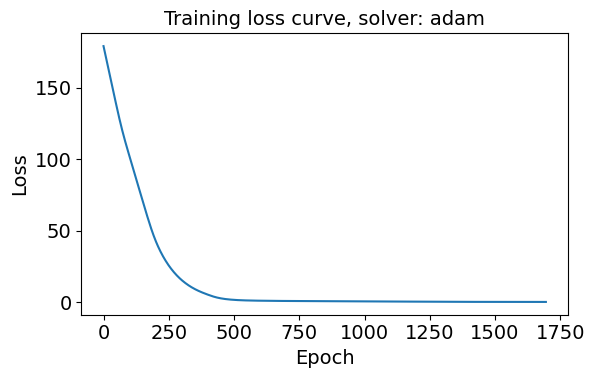

MSE: 0.11 dB

Max error: 1.2 dB

Minimal margin to avoid disruptions 1.1 dB

Error histogram

-1.2 dB: 1 times
-1.1 dB: 1 times
-0.8 dB: 1 times
-0.7 dB: 3 times
-0.6 dB: 5 times
-0.5 dB: 9 times
-0.4 dB: 15 times
-0.3 dB: 17 times
-0.2 dB: 15 times
-0.1 dB: 26 times
0.0 dB: 27 times
0.1 dB: 25 times
0.2 dB: 26 times
0.3 dB: 9 times
0.4 dB: 11 times
0.5 dB: 7 times
0.6 dB: 7 times
0.9 dB: 1 times
1.1 dB: 1 times


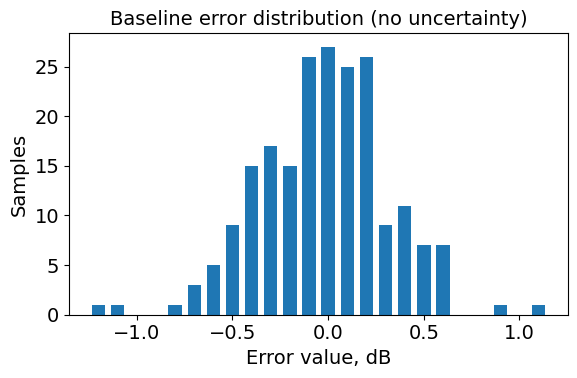

In [ ]:
# ======================================
# BASELINE NN (NO SPAN-LENGTH UNCERTAINTY)
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X_nominal, y, test_size=TEST_SIZE, shuffle=True, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

NNregr_base, _ = train_NN(X_train, y_train, ACTIVATION, NEURONS, LAYERS)
y_pred_base = NNregr_base.predict(X_test)
baseline_metrics = perf_eval(y_test, y_pred_base, 'Baseline error distribution (no uncertainty)')


5%*max_span_length
****************************
Training a NN...
Total number of iterations: 1707
Current loss: 0.065
Best loss: 0.065
Training time [s]: 4.952
Final training R2 score is: 0.971
Final training MSE is: 0.131


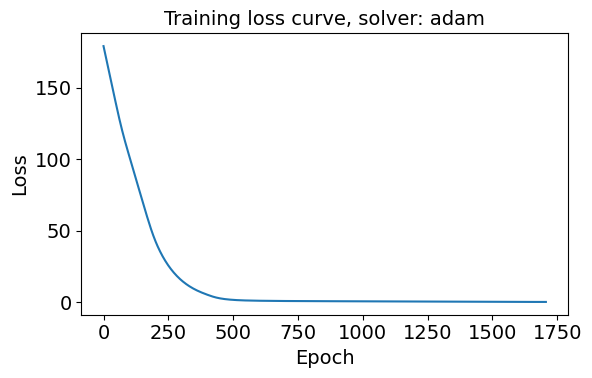

MSE: 0.11 dB

Max error: 1.27 dB

Minimal margin to avoid disruptions 1.2 dB

Error histogram

-1.3 dB: 1 times
-1.0 dB: 1 times
-0.8 dB: 2 times
-0.7 dB: 2 times
-0.6 dB: 2 times
-0.5 dB: 7 times
-0.4 dB: 17 times
-0.3 dB: 19 times
-0.2 dB: 18 times
-0.1 dB: 21 times
-0.0 dB: 26 times
0.1 dB: 32 times
0.2 dB: 19 times
0.3 dB: 14 times
0.4 dB: 6 times
0.5 dB: 10 times
0.6 dB: 8 times
1.0 dB: 1 times
1.1 dB: 1 times


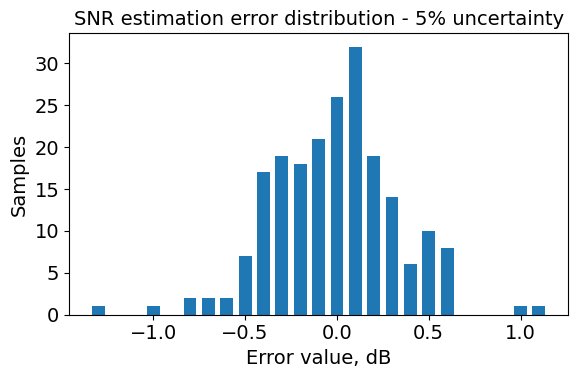

10%*max_span_length
****************************
Training a NN...
Total number of iterations: 1718
Current loss: 0.069
Best loss: 0.069
Training time [s]: 4.233
Final training R2 score is: 0.969
Final training MSE is: 0.138


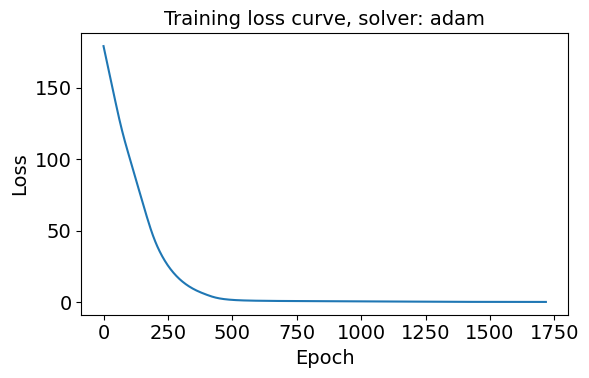

MSE: 0.13 dB

Max error: 1.31 dB

Minimal margin to avoid disruptions 1.3 dB

Error histogram

-1.3 dB: 1 times
-1.0 dB: 1 times
-0.9 dB: 1 times
-0.8 dB: 1 times
-0.7 dB: 3 times
-0.6 dB: 6 times
-0.5 dB: 6 times
-0.4 dB: 19 times
-0.3 dB: 18 times
-0.2 dB: 16 times
-0.1 dB: 24 times
0.0 dB: 23 times
0.1 dB: 26 times
0.2 dB: 14 times
0.3 dB: 20 times
0.4 dB: 11 times
0.5 dB: 6 times
0.6 dB: 5 times
0.7 dB: 3 times
0.8 dB: 1 times
1.1 dB: 1 times
1.3 dB: 1 times


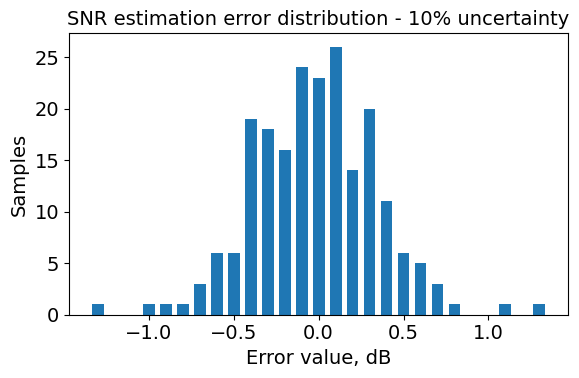

15%*max_span_length
****************************
Training a NN...
Total number of iterations: 1700
Current loss: 0.075
Best loss: 0.075
Training time [s]: 3.507
Final training R2 score is: 0.966
Final training MSE is: 0.151


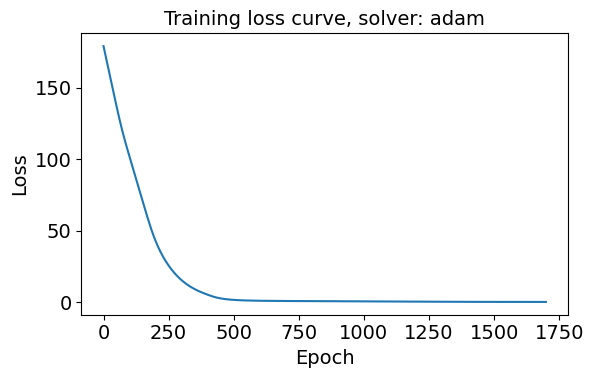

MSE: 0.14 dB

Max error: 1.33 dB

Minimal margin to avoid disruptions 1.3 dB

Error histogram

-1.3 dB: 1 times
-0.9 dB: 3 times
-0.7 dB: 4 times
-0.6 dB: 5 times
-0.5 dB: 10 times
-0.4 dB: 13 times
-0.3 dB: 16 times
-0.2 dB: 19 times
-0.1 dB: 22 times
-0.0 dB: 23 times
0.1 dB: 30 times
0.2 dB: 18 times
0.3 dB: 9 times
0.4 dB: 11 times
0.5 dB: 7 times
0.6 dB: 7 times
0.7 dB: 4 times
0.8 dB: 3 times
1.0 dB: 1 times
1.2 dB: 1 times


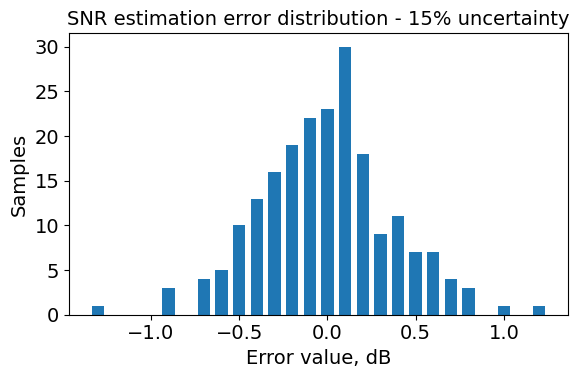

In [ ]:
# ======================================
# TASK 7b: UNCERTAINTY SCENARIOS (5/10/15%)
# ======================================

span_std_list = [0.05 * max_span_length, 0.10 * max_span_length, 0.15 * max_span_length]

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

homework_results = []

for span_std in span_std_list:
    std_perc = int(round(100 * span_std / max_span_length))

    print(str(std_perc) + '%*max_span_length')
    print('*' * 28)

    X_uncertain = extract_UNCERTAIN_features(spans, interferers, span_std)

    X_train_unc, X_test_unc, y_train_unc, y_test_unc = train_test_split(
        X_uncertain, y, test_size=TEST_SIZE, shuffle=True, random_state=RANDOM_STATE
    )

    scaler_unc = StandardScaler()
    X_train_unc = scaler_unc.fit_transform(X_train_unc)
    X_test_unc = scaler_unc.transform(X_test_unc)

    NNregr_unc, _ = train_NN(X_train_unc, y_train_unc, ACTIVATION, NEURONS, LAYERS)

    y_pred_unc = NNregr_unc.predict(X_test_unc)
    metrics_unc = perf_eval(y_test_unc, y_pred_unc, 'SNR estimation error distribution - {}% uncertainty'.format(std_perc))

    homework_results.append({
        'sigma_percent': std_perc,
        'mse': metrics_unc['mse'],
        'max_error': metrics_unc['max_error'],
        'min_margin': metrics_unc['min_margin']
    })


In [ ]:
# ===============================
# NUMERIC SUMMARY
# ===============================

print('Summary metrics by uncertainty level:')
for item in homework_results:
    print('{}%*max_span_length -> MSE: {} dB, Max error: {} dB, Min margin: {} dB'.format(
        item['sigma_percent'], item['mse'], item['max_error'], item['min_margin']
    ))


Summary metrics by uncertainty level:
5%*max_span_length -> MSE: 0.11 dB, Max error: 1.27 dB, Min margin: 1.2 dB
10%*max_span_length -> MSE: 0.13 dB, Max error: 1.31 dB, Min margin: 1.3 dB
15%*max_span_length -> MSE: 0.14 dB, Max error: 1.33 dB, Min margin: 1.3 dB


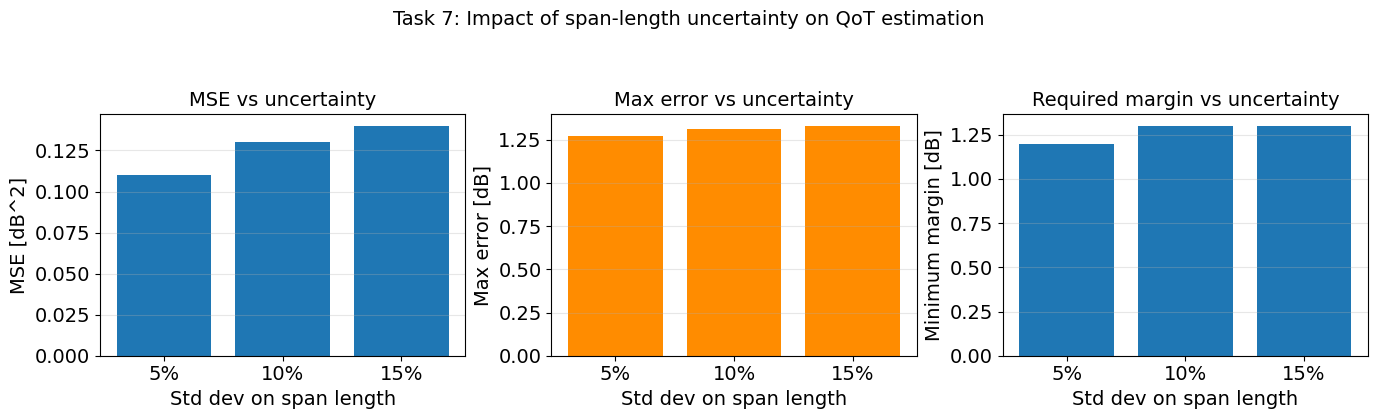

In [ ]:
# ===============================
# COMPARISON PLOTS
# ===============================

sigma_labels = [str(item['sigma_percent']) + '%' for item in homework_results]
mse_values = [item['mse'] for item in homework_results]
maxerr_values = [item['max_error'] for item in homework_results]
margin_values = [item['min_margin'] for item in homework_results]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].bar(sigma_labels, mse_values)
axs[0].set_title('MSE vs uncertainty')
axs[0].set_xlabel('Std dev on span length')
axs[0].set_ylabel('MSE [dB^2]')
axs[0].grid(axis='y', alpha=0.3)

axs[1].bar(sigma_labels, maxerr_values, color='darkorange')
axs[1].set_title('Max error vs uncertainty')
axs[1].set_xlabel('Std dev on span length')
axs[1].set_ylabel('Max error [dB]')
axs[1].grid(axis='y', alpha=0.3)

axs[2].bar(sigma_labels, margin_values)
axs[2].set_title('Required margin vs uncertainty')
axs[2].set_xlabel('Std dev on span length')
axs[2].set_ylabel('Minimum margin [dB]')
axs[2].grid(axis='y', alpha=0.3)

plt.suptitle('Task 7: Impact of span-length uncertainty on QoT estimation', y=1.05)
plt.tight_layout()
plt.show()


##Comment on the obtained result

As uncertainty increases from 5% to 15%, the model generally shows wider error dispersion and tends to require a larger SNR protection margin. This is expected because path-length perturbations directly affect the total path length and longest span.